In [2]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_dense_adj, erdos_renyi_graph, dense_to_sparse
import matplotlib.pyplot as plt

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# 加载 Cora 数据集
dataset = Planetoid(root='./Cora', name='Cora')
data = dataset[0].to(device)

# 预处理：生成稠密邻接矩阵 A (用于 Task 1)
# 注意：这里生成的 adj 是 shape (N, N) 的 Tensor
adj = to_dense_adj(data.edge_index)[0].to(device)

print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges}")
print(f"Features: {dataset.num_features}, Classes: {dataset.num_classes}")

Processing...
Done!


Nodes: 2708, Edges: 10556
Features: 1433, Classes: 7


In [3]:
class DenseGCNLayer(nn.Module):
    def __init__(self, in_size, out_size):
        super(DenseGCNLayer, self).__init__()
        self.W = nn.Linear(in_size, out_size, bias=False) # 公式中通常只有 W，bias 可选

    def forward(self, A, X):
        """
        A: adjacency matrix, shape: (N, N)
        X: input feature matrix, shape: (N, in_size)
        return: output feature matrix, shape: (N, out_size)
        """
        N = A.size(0)
        A_hat = A + torch.eye(N, device=A.device)
        D_hat_diag = torch.sum(A_hat, dim=1)
        D_inv_sqrt = torch.pow(D_hat_diag, -0.5)
        D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0.
        D_inv_sqrt_mat = torch.diag(D_inv_sqrt)
        support = self.W(X) 
        norm_A = D_inv_sqrt_mat @ A_hat @ D_inv_sqrt_mat
        output = norm_A @ support
        return output

In [10]:
class DenseGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DenseGCN, self).__init__()
        self.gcn1 = DenseGCNLayer(input_dim, hidden_dim)
        self.gcn2 = DenseGCNLayer(hidden_dim, output_dim)
        
    def forward(self, A, X):
        x = self.gcn1(A, X)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gcn2(A, x)
        return F.log_softmax(x, dim=1)

# 初始化模型
dense_model = DenseGCN(dataset.num_features, 16, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(dense_model.parameters(), lr=0.01, weight_decay=5e-4)

In [11]:
def train_dense():
    dense_model.train()
    optimizer.zero_grad()
    out = dense_model(adj, data.x)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test_dense():
    dense_model.eval()
    logits, accs = dense_model(adj, data.x), []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        pred = logits[mask].max(1)[1]
        acc = pred.eq(data.y[mask]).sum().item() / mask.sum().item()
        accs.append(acc)
    return accs

print("Start Training Dense GCN...")
for epoch in range(200):
    loss = train_dense()
    if epoch % 20 == 0:
        train_acc, val_acc, test_acc = test_dense()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}')

Start Training Dense GCN...
Epoch: 000, Loss: 1.9481, Train: 0.8714, Val: 0.5780, Test: 0.5870
Epoch: 020, Loss: 0.3382, Train: 0.9857, Val: 0.7860, Test: 0.8050
Epoch: 040, Loss: 0.0900, Train: 1.0000, Val: 0.7720, Test: 0.7970
Epoch: 060, Loss: 0.0578, Train: 1.0000, Val: 0.7700, Test: 0.8030
Epoch: 080, Loss: 0.0598, Train: 1.0000, Val: 0.7900, Test: 0.8080
Epoch: 100, Loss: 0.0492, Train: 1.0000, Val: 0.7780, Test: 0.8110
Epoch: 120, Loss: 0.0398, Train: 1.0000, Val: 0.7800, Test: 0.8140
Epoch: 140, Loss: 0.0469, Train: 1.0000, Val: 0.7720, Test: 0.8070
Epoch: 160, Loss: 0.0436, Train: 1.0000, Val: 0.7720, Test: 0.8030
Epoch: 180, Loss: 0.0355, Train: 1.0000, Val: 0.7700, Test: 0.8060


In [4]:
from torch_geometric.utils import add_self_loops, degree
from torch_scatter import scatter_add

class SparseGCNLayer(nn.Module):
    def __init__(self, in_size, out_size):
        super(SparseGCNLayer, self).__init__()
        self.W = nn.Linear(in_size, out_size, bias=False)

    def forward(self, edge_index, X):
        """
        edge_index: edge index tensor, shape: (2, E)
        X: input feature matrix, shape: (N, in_size)
        return: output feature matrix, shape: (N, out_size)
        """
        N = X.size(0)
        x_p = self.W(X)
        edge_index, _ = add_self_loops(edge_index, num_nodes=N)
        degrees = degree(edge_index[0], N)
        degrees_inv_sqrt = degrees.pow(-0.5)
        degrees_inv_sqrt[torch.isinf(degrees_inv_sqrt)] = 0.
        
        norm = degrees_inv_sqrt[edge_index[0]] * degrees_inv_sqrt[edge_index[1]]
        msg = x_p[edge_index[0]] * norm.view(-1, 1)
        out = scatter_add(msg, edge_index[1], dim=0, dim_size=N)
        return out
        

In [17]:
# 验证逻辑：
# 1. 实例化 Dense 和 Sparse 两个层
# 2. 将 Dense 层的权重直接复制给 Sparse 层
# 3. 对比输出是否全等 (allclose)

def verify_consistency():
    in_dim, out_dim = 16, 8
    x_input = torch.randn(data.num_nodes, in_dim).to(device)
    
    # 实例化
    dense_layer = DenseGCNLayer(in_dim, out_dim).to(device)
    sparse_layer = SparseGCNLayer(in_dim, out_dim).to(device)
    
    # 强行同步权重
    with torch.no_grad():
        sparse_layer.W.weight.data = dense_layer.W.weight.data.clone()
        if dense_layer.W.bias is not None:
            sparse_layer.W.bias.data = dense_layer.W.bias.data.clone()
            
    # 前向传播
    dense_out = dense_layer(adj, x_input)
    sparse_out = sparse_layer(data.edge_index, x_input)
    
    # 检查差异
    diff = (dense_out - sparse_out).abs().max()
    print(f"Max difference between Dense and Sparse: {diff.item()}")
    
    if torch.allclose(dense_out, sparse_out, atol=1e-5):
        print(">> Verification PASSED: Outputs are identical.")
    else:
        print(">> Verification FAILED: Outputs differ.")

# 在实现好 Layer 后取消注释运行
verify_consistency()

Max difference between Dense and Sparse: 1.1920928955078125e-07
>> Verification PASSED: Outputs are identical.


In [4]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch_geometric.utils import to_dense_adj, erdos_renyi_graph
import gc

def benchmark_efficiency(n_nodes, avg_degree=10):
    # 核心修复：根据节点数动态调整 p，而不是固定 p=0.005
    # 对于 100k 节点，p 自动变成 0.0001，生成约 100万条边，而不是 5000万条
    edge_prob = avg_degree / n_nodes
    
    print(f"Benchmarking N={n_nodes}...", end=" ")
    
    # 1. 生成图
    try:
        edge_index = erdos_renyi_graph(n_nodes, edge_prob).to(device)
    except Exception as e:
        print(f"Graph Gen Failed: {e}")
        return None, None

    x = torch.randn(n_nodes, 64).to(device)
    
    # 2. 准备模型
    # Dense 层只在小图时初始化，节省内存
    sparse_layer = SparseGCNLayer(64, 16).to(device)
    
    # 3. 测速 Dense (只测 10k 以下)
    DENSE_LIMIT = 10000 
    t_dense = float('inf')
    
    if n_nodes <= DENSE_LIMIT:
        try:
            dense_layer = DenseGCNLayer(64, 16).to(device)
            adj_dense = to_dense_adj(edge_index, max_num_nodes=n_nodes)[0]
            
            start = time.time()
            _ = dense_layer(adj_dense, x)
            t_dense = time.time() - start
            
            # 立即释放内存
            del adj_dense, dense_layer
        except:
            print("(Dense OOM)", end=" ")
    else:
        print("(Skip Dense)", end=" ")
    
    # 4. 测速 Sparse (核心目标)
    try:
        start = time.time()
        _ = sparse_layer(edge_index, x)
        t_sparse = time.time() - start
    except RuntimeError:
        print("(Sparse OOM)", end=" ")
        t_sparse = float('inf')
    
    print(f"-> Sparse: {t_sparse:.4f}s")
    
    # 暴力清理内存
    del edge_index, x, sparse_layer
    gc.collect()
    
    return t_dense, t_sparse

# 测试配置
node_counts = [1000, 5000, 10000, 20000, 50000, 100000]
results = {'nodes': [], 'dense_time': [], 'sparse_time': []}

print("Starting Benchmark (CPU Safe Mode)...")

for N in node_counts:
    t_d, t_s = benchmark_efficiency(N)
    if t_s is not None:
        results['nodes'].append(N)
        results['dense_time'].append(t_d)
        results['sparse_time'].append(t_s)

# 绘图
plt.figure(figsize=(10, 6))
# 只画 Dense 成功的数据点
valid_idx = [i for i, t in enumerate(results['dense_time']) if t != float('inf')]
plt.plot([results['nodes'][i] for i in valid_idx], [results['dense_time'][i] for i in valid_idx], label='Dense GCN', marker='o')
plt.plot(results['nodes'], results['sparse_time'], label='Sparse GCN', marker='o')
plt.xlabel('Number of Nodes')
plt.ylabel('Time (seconds)')
plt.title('Dense vs Sparse GCN Efficiency (CPU)')
plt.legend()
plt.grid(True)
plt.show()

Starting Benchmark (CPU Safe Mode)...
Benchmarking N=1000... -> Sparse: 0.0569s
Benchmarking N=5000... -> Sparse: 0.0035s
Benchmarking N=10000... -> Sparse: 0.0056s
Benchmarking N=20000... (Skip Dense) -> Sparse: 0.0068s
Benchmarking N=50000... 

: 

Starting Benchmark (CPU Safe Mode)...
Benchmarking N=1000... -> Sparse: 0.0008s
Benchmarking N=5000... -> Sparse: 0.0032s
Benchmarking N=10000... -> Sparse: 0.0063s
Benchmarking N=20000... -> Sparse: 0.0088s


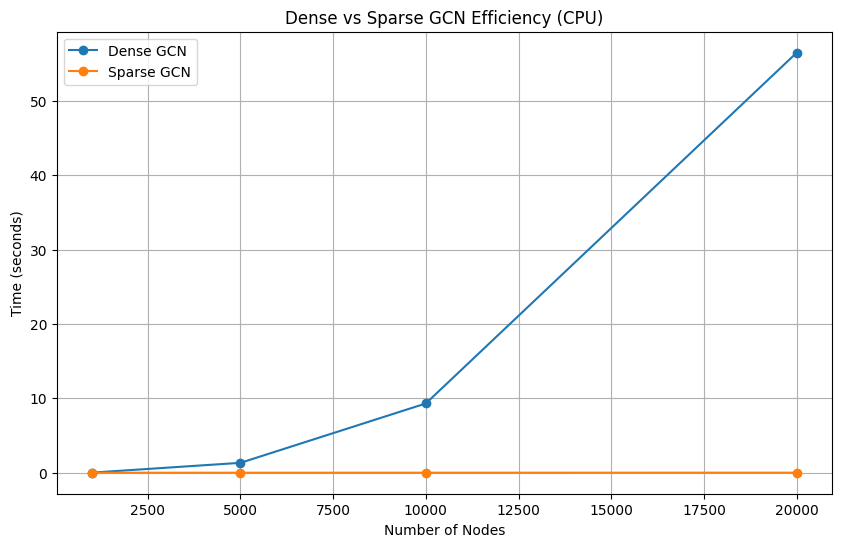

In [6]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch_geometric.utils import to_dense_adj, erdos_renyi_graph
import gc

def benchmark_efficiency(n_nodes, avg_degree=10):
    # 核心修复：根据节点数动态调整 p，而不是固定 p=0.005
    # 对于 100k 节点，p 自动变成 0.0001，生成约 100万条边，而不是 5000万条
    edge_prob = avg_degree / n_nodes
    
    print(f"Benchmarking N={n_nodes}...", end=" ")
    
    # 1. 生成图
    try:
        edge_index = erdos_renyi_graph(n_nodes, edge_prob).to(device)
    except Exception as e:
        print(f"Graph Gen Failed: {e}")
        return None, None

    x = torch.randn(n_nodes, 64).to(device)
    
    # 2. 准备模型
    # Dense 层只在小图时初始化，节省内存
    sparse_layer = SparseGCNLayer(64, 16).to(device)
    
    # 3. 测速 Dense (只测 20k 以下)
    DENSE_LIMIT = 20000 
    t_dense = float('inf')
    
    if n_nodes <= DENSE_LIMIT:
        try:
            dense_layer = DenseGCNLayer(64, 16).to(device)
            adj_dense = to_dense_adj(edge_index, max_num_nodes=n_nodes)[0]
            
            start = time.time()
            _ = dense_layer(adj_dense, x)
            t_dense = time.time() - start
            
            # 立即释放内存
            del adj_dense, dense_layer
        except:
            print("(Dense OOM)", end=" ")
    else:
        print("(Skip Dense)", end=" ")
    
    # 4. 测速 Sparse (核心目标)
    try:
        start = time.time()
        _ = sparse_layer(edge_index, x)
        t_sparse = time.time() - start
    except RuntimeError:
        print("(Sparse OOM)", end=" ")
        t_sparse = float('inf')
    
    print(f"-> Sparse: {t_sparse:.4f}s")
    
    # 暴力清理内存
    del edge_index, x, sparse_layer
    gc.collect()
    
    return t_dense, t_sparse

# 测试配置
node_counts = [1000, 5000, 10000, 20000]
results = {'nodes': [], 'dense_time': [], 'sparse_time': []}

print("Starting Benchmark (CPU Safe Mode)...")

for N in node_counts:
    t_d, t_s = benchmark_efficiency(N)
    if t_s is not None:
        results['nodes'].append(N)
        results['dense_time'].append(t_d)
        results['sparse_time'].append(t_s)

# 绘图
plt.figure(figsize=(10, 6))
# 只画 Dense 成功的数据点
valid_idx = [i for i, t in enumerate(results['dense_time']) if t != float('inf')]
plt.plot([results['nodes'][i] for i in valid_idx], [results['dense_time'][i] for i in valid_idx], label='Dense GCN', marker='o')
plt.plot(results['nodes'], results['sparse_time'], label='Sparse GCN', marker='o')
plt.xlabel('Number of Nodes')
plt.ylabel('Time (seconds)')
plt.title('Dense vs Sparse GCN Efficiency (CPU)')
plt.legend()
plt.grid(True)
plt.show()

50k.100k的时，Dense GCN oom了；50k的时候，kernel崩溃了。

# 结论
对于图卷积，在Cora中获得了约0.81的准确率。这个准确率和报道是接近的。其没有能达到更高准确率的主要原因是过拟合问题。由于Cora图相对较小，这个问题没有很好的解决方案。  
关于稀疏图卷积和密集图卷积，我们容易观察到，密集图卷积的内存消耗和时间消耗都是$O(n^2)$的，而稀疏图卷积为$O(E)$.在密集图中，二者差异不大。但是对于稀疏图，一般来说$E << n^2$,此时稀疏图卷积会有很明显的优势。